# ROGII Wellbore Geology Prediction
## Notebook 03 – Dataset-Wide Exploratory Data Analysis

### Objectives

- Analyse all training well pairs.
- Compare well sizes and prediction-zone lengths.
- Measure missing values across wells.
- Validate the `TVT_input` prediction boundary.
- Study TVT, GR, and trajectory relationships.
- Identify unusual or difficult wells.
- Produce a summary dataset for modelling.

### 1. Import Libraries

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

### 2. Configure Project Paths

In [2]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

TRAIN_DIR = RAW_DIR / "train"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT.resolve())
print("Training directory exists:", TRAIN_DIR.exists())
print("Processed directory exists:", PROCESSED_DIR.exists())

Project root: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology
Training directory exists: True
Processed directory exists: True


### 3. Discover Training Well Pairs

In [3]:
typewell_files = sorted(TRAIN_DIR.glob("*_typewell.csv"))
horizontal_files = sorted(TRAIN_DIR.glob("*_horizontal_well.csv"))

typewell_map = {
    file.name.replace("_typewell.csv", ""): file
    for file in typewell_files
}

horizontal_map = {
    file.name.replace("_horizontal_well.csv", ""): file
    for file in horizontal_files
}

typewell_ids = set(typewell_map)
horizontal_ids = set(horizontal_map)

complete_ids = sorted(typewell_ids & horizontal_ids)

print("Typewell files:", len(typewell_files))
print("Horizontal files:", len(horizontal_files))
print("Complete well pairs:", len(complete_ids))
print("Missing horizontal wells:", len(typewell_ids - horizontal_ids))
print("Missing typewells:", len(horizontal_ids - typewell_ids))

Typewell files: 773
Horizontal files: 773
Complete well pairs: 773
Missing horizontal wells: 0
Missing typewells: 0


### 4. Create Helper Functions

In [4]:
def safe_correlation(first_series, second_series):
    valid_data = pd.DataFrame({
        "first": first_series,
        "second": second_series
    }).dropna()

    if len(valid_data) < 2:
        return np.nan

    if valid_data["first"].nunique() < 2:
        return np.nan

    if valid_data["second"].nunique() < 2:
        return np.nan

    return valid_data.corr().iloc[0, 1]

In [5]:
def calculate_prefix_slope(horizontal_data, known_mask, window):
    visible_data = (
        horizontal_data
        .loc[known_mask, ["MD", "TVT_input"]]
        .dropna()
        .tail(window)
    )

    if len(visible_data) < 2:
        return np.nan

    slope, _ = np.polyfit(
        visible_data["MD"],
        visible_data["TVT_input"],
        1
    )

    return slope

In [6]:
def longest_missing_run(series):
    missing_mask = series.isna().to_numpy()

    longest_run = 0
    current_run = 0

    for is_missing in missing_mask:
        if is_missing:
            current_run += 1
            longest_run = max(longest_run, current_run)
        else:
            current_run = 0

    return longest_run

### 5. Create the Well Summary Function

In [7]:
FORMATION_COLUMNS = [
    "ANCC",
    "ASTNU",
    "ASTNL",
    "EGFDU",
    "EGFDL",
    "BUDA"
]


def summarize_well(well_id):
    typewell = pd.read_csv(typewell_map[well_id])
    horizontal = pd.read_csv(horizontal_map[well_id])

    known_mask = horizontal["TVT_input"].notna()
    prediction_mask = ~known_mask

    known_positions = np.flatnonzero(known_mask.to_numpy())
    prediction_positions = np.flatnonzero(prediction_mask.to_numpy())

    known_rows = int(known_mask.sum())
    prediction_rows = int(prediction_mask.sum())

    if len(prediction_positions) > 0:
        prediction_start_position = int(prediction_positions[0])

        prediction_start_md = horizontal.iloc[
            prediction_start_position
        ]["MD"]

        clean_boundary = (
            known_mask.iloc[:prediction_start_position].all()
            and prediction_mask.iloc[prediction_start_position:].all()
        )
    else:
        prediction_start_position = None
        prediction_start_md = np.nan
        clean_boundary = True

    if len(known_positions) > 0:
        last_known_position = int(known_positions[-1])

        last_known_md = horizontal.iloc[
            last_known_position
        ]["MD"]

        last_known_tvt = horizontal.iloc[
            last_known_position
        ]["TVT_input"]
    else:
        last_known_md = np.nan
        last_known_tvt = np.nan

    if known_rows > 0:
        tvt_input_matches_tvt = np.allclose(
            horizontal.loc[known_mask, "TVT_input"],
            horizontal.loc[known_mask, "TVT"]
        )
    else:
        tvt_input_matches_tvt = False

    typewell_tvt_min = typewell["TVT"].min()
    typewell_tvt_max = typewell["TVT"].max()

    horizontal_tvt_min = horizontal["TVT"].min()
    horizontal_tvt_max = horizontal["TVT"].max()

    available_formations = [
        column
        for column in FORMATION_COLUMNS
        if column in horizontal.columns
    ]

    if available_formations:
        formation_missing_percentage = (
            horizontal[available_formations]
            .isna()
            .mean()
            .mean()
            * 100
        )
    else:
        formation_missing_percentage = np.nan

    prediction_gr_missing_percentage = (
        horizontal.loc[prediction_mask, "GR"].isna().mean() * 100
        if prediction_rows > 0
        else 0
    )

    return {
        "Well_ID": well_id,

        "Typewell_Rows": len(typewell),
        "Horizontal_Rows": len(horizontal),

        "Known_Rows": known_rows,
        "Prediction_Rows": prediction_rows,
        "Prediction_Percentage": (
            prediction_rows / len(horizontal) * 100
        ),

        "Prediction_Start_MD": prediction_start_md,
        "Last_Known_MD": last_known_md,
        "Last_Known_TVT": last_known_tvt,

        "Clean_Prediction_Boundary": clean_boundary,
        "TVT_Input_Matches_TVT": tvt_input_matches_tvt,

        "MD_Min": horizontal["MD"].min(),
        "MD_Max": horizontal["MD"].max(),
        "Median_MD_Step": horizontal["MD"].diff().median(),
        "MD_Is_Monotonic": horizontal["MD"].is_monotonic_increasing,

        "Typewell_TVT_Min": typewell_tvt_min,
        "Typewell_TVT_Max": typewell_tvt_max,
        "Typewell_TVT_Range": typewell_tvt_max - typewell_tvt_min,
        "Median_Typewell_TVT_Step": typewell["TVT"].diff().median(),
        "Typewell_TVT_Is_Monotonic": typewell["TVT"].is_monotonic_increasing,

        "Horizontal_TVT_Min": horizontal_tvt_min,
        "Horizontal_TVT_Max": horizontal_tvt_max,
        "Horizontal_TVT_Range": (
            horizontal_tvt_max - horizontal_tvt_min
        ),

        "Typewell_Covers_Horizontal_TVT": (
            typewell_tvt_min <= horizontal_tvt_min
            and typewell_tvt_max >= horizontal_tvt_max
        ),

        "GR_Missing_Percentage": (
            horizontal["GR"].isna().mean() * 100
        ),

        "Prediction_GR_Missing_Percentage": (
            prediction_gr_missing_percentage
        ),

        "Longest_GR_Missing_Run": longest_missing_run(
            horizontal["GR"]
        ),

        "Geology_Missing_Percentage": (
            typewell["Geology"].isna().mean() * 100
        ),

        "Formation_Missing_Percentage": (
            formation_missing_percentage
        ),

        "Z_TVT_Correlation": safe_correlation(
            horizontal["Z"],
            horizontal["TVT"]
        ),

        "GR_TVT_Correlation": safe_correlation(
            horizontal["GR"],
            horizontal["TVT"]
        ),

        "Prefix_Slope_Last_10": calculate_prefix_slope(
            horizontal,
            known_mask,
            window=10
        ),

        "Prefix_Slope_Last_50": calculate_prefix_slope(
            horizontal,
            known_mask,
            window=50
        ),

        "Prefix_Slope_Last_100": calculate_prefix_slope(
            horizontal,
            known_mask,
            window=100
        ),

        "Typewell_Duplicate_Rows": typewell.duplicated().sum(),
        "Horizontal_Duplicate_Rows": horizontal.duplicated().sum()
    }

### 6. Process All Training Wells

In [8]:
well_summaries = []
failed_wells = []

for index, well_id in enumerate(complete_ids, start=1):
    try:
        well_summaries.append(
            summarize_well(well_id)
        )
    except Exception as error:
        failed_wells.append({
            "Well_ID": well_id,
            "Error": str(error)
        })

    if index % 100 == 0:
        print(f"Processed {index} wells")

well_summary = pd.DataFrame(well_summaries)

print("\nSummary shape:", well_summary.shape)
print("Failed wells:", len(failed_wells))

display(well_summary.head())

Processed 100 wells
Processed 200 wells
Processed 300 wells
Processed 400 wells
Processed 500 wells
Processed 600 wells
Processed 700 wells

Summary shape: (773, 36)
Failed wells: 0


,Well_ID,Typewell_Rows,Horizontal_Rows,Known_Rows,Prediction_Rows,Prediction_Percentage,Prediction_Start_MD,Last_Known_MD,Last_Known_TVT,Clean_Prediction_Boundary,TVT_Input_Matches_TVT,MD_Min,MD_Max,Median_MD_Step,MD_Is_Monotonic,Typewell_TVT_Min,Typewell_TVT_Max,Typewell_TVT_Range,Median_Typewell_TVT_Step,Typewell_TVT_Is_Monotonic,Horizontal_TVT_Min,Horizontal_TVT_Max,Horizontal_TVT_Range,Typewell_Covers_Horizontal_TVT,GR_Missing_Percentage,Prediction_GR_Missing_Percentage,Longest_GR_Missing_Run,Geology_Missing_Percentage,Formation_Missing_Percentage,Z_TVT_Correlation,GR_TVT_Correlation,Prefix_Slope_Last_10,Prefix_Slope_Last_50,Prefix_Slope_Last_100,Typewell_Duplicate_Rows,Horizontal_Duplicate_Rows
0,000d7d20_,1296,5278,1442,3836,72.6790,"12,909.0000","12,908.0000","11,747.3700",True,True,"11,467.0000","16,744.0000",1.0000,True,"11,223.9500","11,871.4500",647.5000,0.5000,True,"11,236.0200","11,756.1200",520.1000,True,42.7814,47.3410,19,23.0710,0.0000,-0.9177,0.0011,0.0113,0.0167,0.0125,0,0
1,00bbac68_,1946,7559,1545,6014,79.5608,"13,123.0000","13,122.0000","12,223.5400",True,True,"11,578.0000","19,136.0000",1.0000,True,"11,394.4500","12,366.9500",972.5000,0.5000,True,"11,406.6300","12,240.0100",833.3800,True,12.4620,13.8344,8,47.3792,0.0000,-0.9076,-0.2420,0.0170,0.0131,0.0076,0,0
2,00e12e8b_,2556,6384,2083,4301,67.3716,"12,539.0000","12,538.0000","11,604.8200",True,True,"10,456.0000","16,839.0000",1.0000,True,"10,593.9500","11,871.4500","1,277.5000",0.5000,True,"10,606.1800","11,616.6400","1,010.4600",True,9.1479,9.7187,8,60.9937,0.0000,-0.9639,-0.7860,0.0415,0.0421,0.0367,0,0
3,015fe0d2_,1265,5950,1654,4296,72.2017,"13,488.0000","13,487.0000","12,233.7800",True,True,"11,834.0000","17,783.0000",1.0000,True,"11,734.9500","12,366.9500",632.0000,0.5000,True,"11,747.2600","12,271.5300",524.2700,True,25.4286,32.0298,9,19.0514,0.0000,-0.9283,0.2037,0.0295,0.0299,0.0259,0,0
4,01869cd4_,1052,6850,1293,5557,81.1241,"12,549.0000","12,548.0000","11,745.9400",True,True,"11,256.0000","18,105.0000",1.0000,True,"11,345.9500","11,871.4500",525.5000,0.5000,True,"11,358.2700","11,767.7500",409.4800,True,47.7080,51.1247,14,5.2281,0.0000,-0.8800,0.0651,0.0010,0.0085,0.0149,0,0


In [9]:
display(pd.DataFrame(failed_wells))

""


### 7. Validate Dataset Quality

In [10]:
quality_checks = pd.Series({
    "Total Well Pairs": len(well_summary),

    "Clean Prediction Boundaries": (
        well_summary["Clean_Prediction_Boundary"].sum()
    ),

    "TVT_input Matches TVT": (
        well_summary["TVT_Input_Matches_TVT"].sum()
    ),

    "Monotonic MD Wells": (
        well_summary["MD_Is_Monotonic"].sum()
    ),

    "Monotonic Typewell TVT": (
        well_summary["Typewell_TVT_Is_Monotonic"].sum()
    ),

    "Typewell Covers Horizontal TVT": (
        well_summary["Typewell_Covers_Horizontal_TVT"].sum()
    ),

    "Wells With Typewell Duplicates": (
        well_summary["Typewell_Duplicate_Rows"] > 0
    ).sum(),

    "Wells With Horizontal Duplicates": (
        well_summary["Horizontal_Duplicate_Rows"] > 0
    ).sum()
})

display(quality_checks.to_frame("Count"))

,Count
Total Well Pairs,773
Clean Prediction Boundaries,773
TVT_input Matches TVT,773
Monotonic MD Wells,773
Monotonic Typewell TVT,773
Typewell Covers Horizontal TVT,760
Wells With Typewell Duplicates,0
Wells With Horizontal Duplicates,0


### 8. Overall Statistical Summary

In [11]:
summary_columns = [
    "Typewell_Rows",
    "Horizontal_Rows",
    "Known_Rows",
    "Prediction_Rows",
    "Prediction_Percentage",
    "Horizontal_TVT_Range",
    "GR_Missing_Percentage",
    "Prediction_GR_Missing_Percentage",
    "Longest_GR_Missing_Run",
    "Geology_Missing_Percentage",
    "Z_TVT_Correlation",
    "GR_TVT_Correlation",
    "Prefix_Slope_Last_10",
    "Prefix_Slope_Last_50",
    "Prefix_Slope_Last_100"
]

display(
    well_summary[summary_columns]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
Typewell_Rows,773.0000,"2,027.2251","1,009.4732",636.0000,"1,498.0000","1,874.0000","2,158.0000","10,043.0000"
Horizontal_Rows,773.0000,"6,587.6520","1,311.4635","2,058.0000","5,706.0000","6,576.0000","7,388.0000","12,141.0000"
Known_Rows,773.0000,"1,692.4528",217.3438,851.0000,"1,546.0000","1,703.0000","1,839.0000","2,392.0000"
Prediction_Rows,773.0000,"4,895.1992","1,301.1784",407.0000,"4,044.0000","4,840.0000","5,694.0000","10,052.0000"
Prediction_Percentage,773.0000,73.3161,6.3776,19.7765,70.0344,73.9991,77.5462,87.5165
Horizontal_TVT_Range,773.0000,734.4689,175.4844,158.9300,588.5700,758.2200,856.5100,"1,256.7000"
GR_Missing_Percentage,773.0000,29.3854,19.0857,0.6527,12.1198,27.7038,46.3952,80.0989
Prediction_GR_Missing_Percentage,773.0000,31.4863,20.5465,0.6709,13.0799,30.2910,49.7708,81.1778
Longest_GR_Missing_Run,773.0000,25.6429,46.6711,1.0000,8.0000,13.0000,19.0000,331.0000
Geology_Missing_Percentage,773.0000,30.5659,16.3822,0.0000,18.6532,35.0759,43.3563,66.4043


### 9. Well Size Distribution

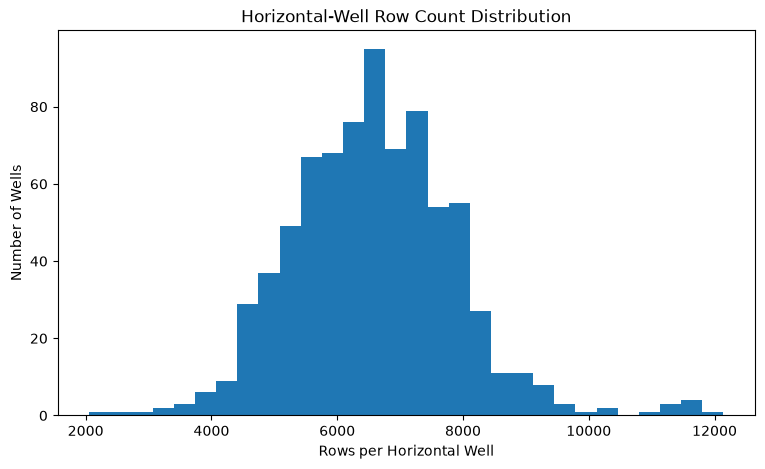

In [12]:
plt.figure(figsize=(9, 5))

well_summary["Horizontal_Rows"].plot(
    kind="hist",
    bins=30
)

plt.title("Horizontal-Well Row Count Distribution")
plt.xlabel("Rows per Horizontal Well")
plt.ylabel("Number of Wells")
plt.show()

### 10. Prediction-Zone Distribution

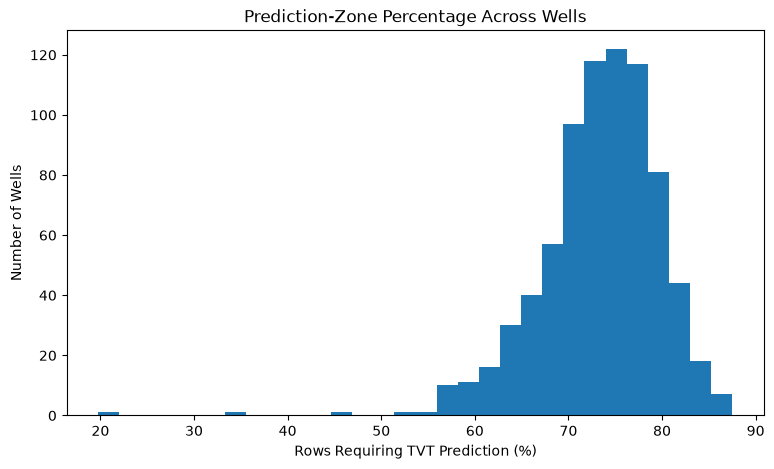

In [13]:
plt.figure(figsize=(9, 5))

well_summary["Prediction_Percentage"].plot(
    kind="hist",
    bins=30
)

plt.title("Prediction-Zone Percentage Across Wells")
plt.xlabel("Rows Requiring TVT Prediction (%)")
plt.ylabel("Number of Wells")
plt.show()

### 11. GR Missingness Distribution

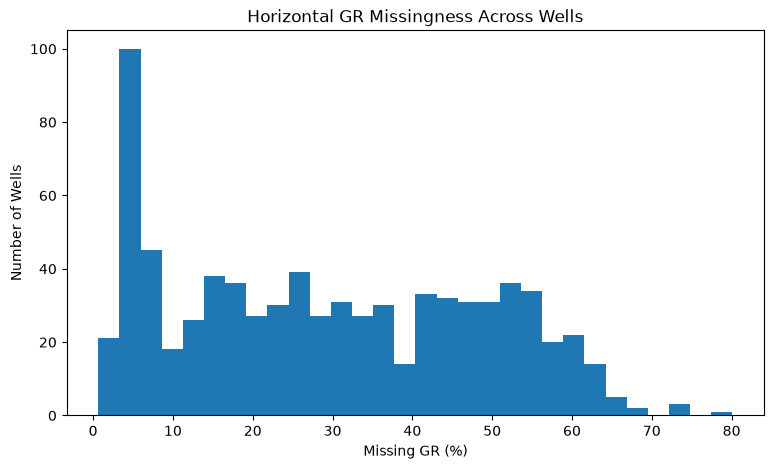

In [14]:
plt.figure(figsize=(9, 5))

well_summary["GR_Missing_Percentage"].plot(
    kind="hist",
    bins=30
)

plt.title("Horizontal GR Missingness Across Wells")
plt.xlabel("Missing GR (%)")
plt.ylabel("Number of Wells")
plt.show()

### 12. GR Missingness in the Prediction Section

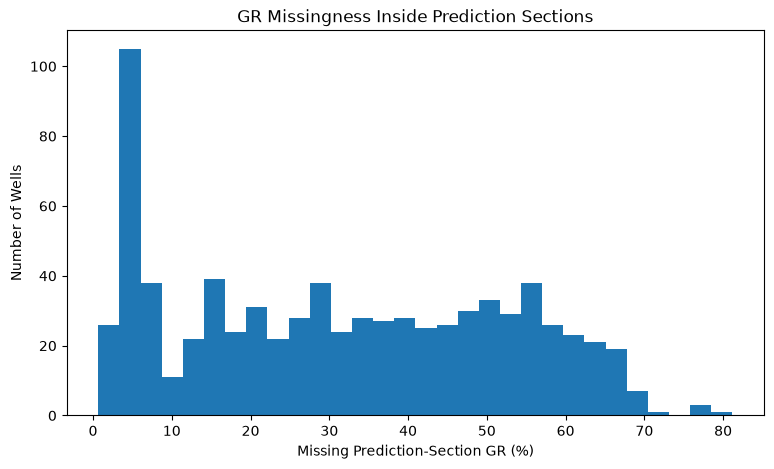

In [15]:
plt.figure(figsize=(9, 5))

well_summary["Prediction_GR_Missing_Percentage"].plot(
    kind="hist",
    bins=30
)

plt.title("GR Missingness Inside Prediction Sections")
plt.xlabel("Missing Prediction-Section GR (%)")
plt.ylabel("Number of Wells")
plt.show()

### 13. Prediction Length vs GR Missingness

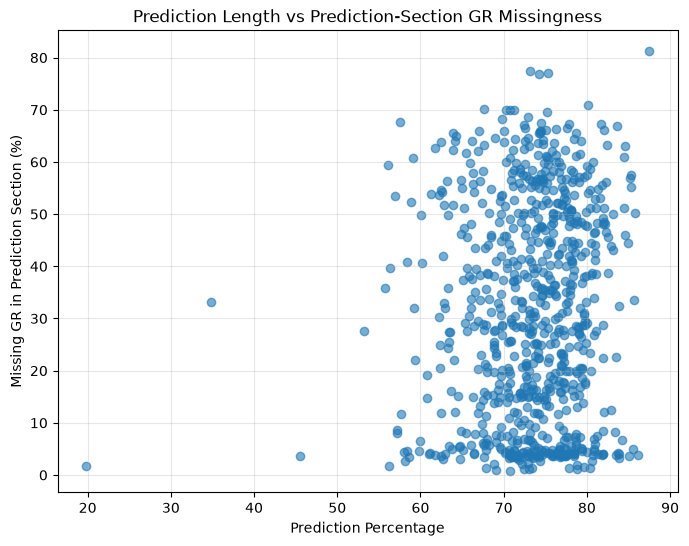

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    well_summary["Prediction_Percentage"],
    well_summary["Prediction_GR_Missing_Percentage"],
    alpha=0.6
)

plt.title("Prediction Length vs Prediction-Section GR Missingness")
plt.xlabel("Prediction Percentage")
plt.ylabel("Missing GR in Prediction Section (%)")
plt.grid(alpha=0.3)
plt.show()

### 14. TVT–Z Correlation Across Wells

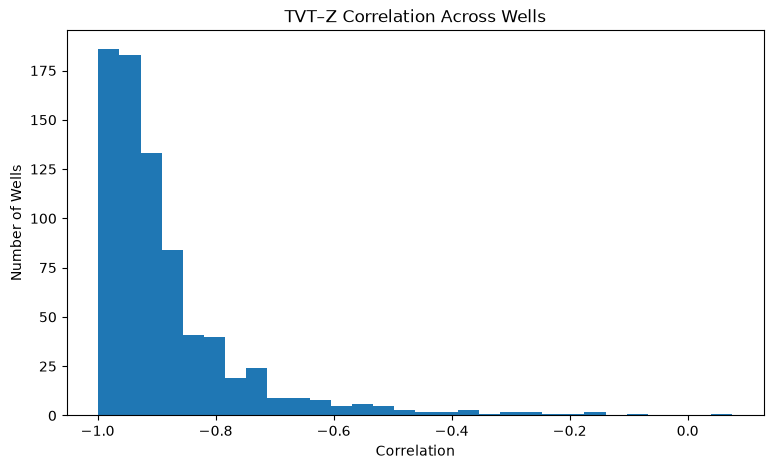

In [17]:
plt.figure(figsize=(9, 5))

well_summary["Z_TVT_Correlation"].dropna().plot(
    kind="hist",
    bins=30
)

plt.title("TVT–Z Correlation Across Wells")
plt.xlabel("Correlation")
plt.ylabel("Number of Wells")
plt.show()

### 15. GR–TVT Correlation Across Wells

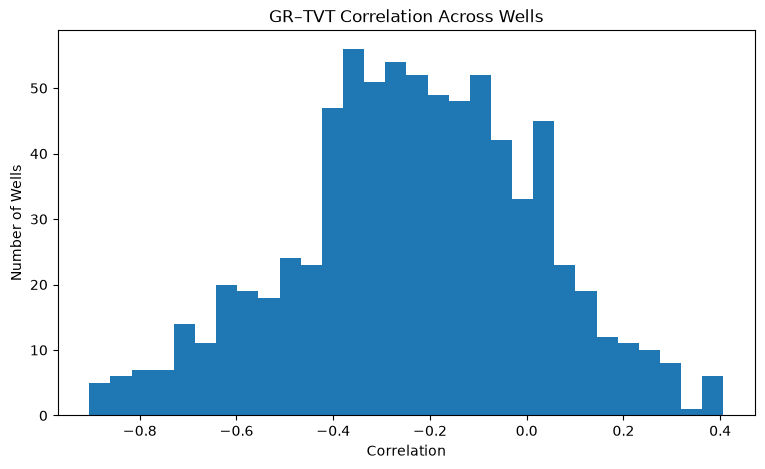

In [18]:
plt.figure(figsize=(9, 5))

well_summary["GR_TVT_Correlation"].dropna().plot(
    kind="hist",
    bins=30
)

plt.title("GR–TVT Correlation Across Wells")
plt.xlabel("Correlation")
plt.ylabel("Number of Wells")
plt.show()

### 16. Recent TVT Slope Distribution

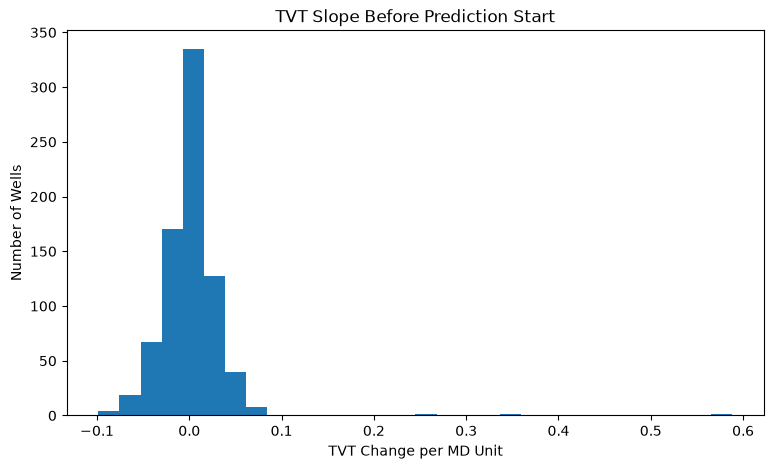

In [19]:
plt.figure(figsize=(9, 5))

well_summary["Prefix_Slope_Last_100"].dropna().plot(
    kind="hist",
    bins=30
)

plt.title("TVT Slope Before Prediction Start")
plt.xlabel("TVT Change per MD Unit")
plt.ylabel("Number of Wells")
plt.show()

### 17. Inspect Difficult Wells

#### Longest prediction sections

In [20]:
display(
    well_summary
    .nlargest(10, "Prediction_Percentage")
    [
        [
            "Well_ID",
            "Horizontal_Rows",
            "Known_Rows",
            "Prediction_Rows",
            "Prediction_Percentage",
            "Prediction_GR_Missing_Percentage"
        ]
    ]
)

,Well_ID,Horizontal_Rows,Known_Rows,Prediction_Rows,Prediction_Percentage,Prediction_GR_Missing_Percentage
383,86454a6f_,9100,1136,7964,87.5165,81.1778
318,6e9ccd38_,9619,1337,8282,86.1004,3.8879
305,684a6fc1_,11449,1631,9818,85.7542,50.2241
211,46d41ff6_,9226,1325,7901,85.6384,33.5021
104,25050f63_,7155,1031,6124,85.5905,4.9967
435,96ae5806_,11527,1688,9839,85.3561,55.2394
521,ae0784a8_,9171,1348,7823,85.3015,57.4716
696,ea3a0e38_,11794,1742,10052,85.2298,56.9140
136,2d9f6cb9_,8627,1289,7338,85.0585,3.6250
157,35b30c7f_,11270,1691,9579,84.9956,44.3888


#### Highest prediction-section GR missingness

In [21]:
display(
    well_summary
    .nlargest(10, "Prediction_GR_Missing_Percentage")
    [
        [
            "Well_ID",
            "Prediction_Percentage",
            "GR_Missing_Percentage",
            "Prediction_GR_Missing_Percentage",
            "Longest_GR_Missing_Run"
        ]
    ]
)

,Well_ID,Prediction_Percentage,GR_Missing_Percentage,Prediction_GR_Missing_Percentage,Longest_GR_Missing_Run
383,86454a6f_,87.5165,80.0989,81.1778,27
127,2be5c96a_,73.1792,72.9706,77.4347,20
241,512943b2_,75.2732,72.8484,77.1326,25
577,c36625df_,74.2562,74.6946,76.9296,25
326,7224331b_,80.1348,68.9796,70.8560,28
524,aed44918_,67.6368,65.7463,70.0625,16
590,c70c0e01_,71.1904,68.3837,70.0371,20
609,cd7f1687_,70.7574,63.7352,70.0142,22
293,62a6f539_,70.3027,62.4405,69.9973,25
751,fa31da94_,75.2432,63.7030,69.5047,19


#### Typewell does not fully cover horizontal TVT

In [22]:
display(
    well_summary.loc[
        ~well_summary["Typewell_Covers_Horizontal_TVT"],
        [
            "Well_ID",
            "Typewell_TVT_Min",
            "Typewell_TVT_Max",
            "Horizontal_TVT_Min",
            "Horizontal_TVT_Max"
        ]
    ]
)

,Well_ID,Typewell_TVT_Min,Typewell_TVT_Max,Horizontal_TVT_Min,Horizontal_TVT_Max
7,02e7fe5a_,"11,782.6200","12,285.1000","11,356.1300","12,199.3900"
27,0bbf5e67_,"10,167.9500","10,971.9500","10,180.1300","10,972.0600"
37,10b89021_,"11,782.6200","12,285.1000","11,311.0800","12,161.1800"
130,2cee0cba_,"10,451.4500","11,245.4500","10,463.6700","11,246.7400"
152,3417285d_,"11,782.6200","12,285.1000","11,137.8500","12,210.6200"
182,3c3dbcbc_,"11,168.9000","12,051.8400","11,051.2400","11,877.6500"
312,6ae68655_,"11,782.6200","12,285.1000","11,387.9800","12,133.5900"
352,7993a768_,"11,782.6200","12,285.1000","11,439.1700","12,172.3000"
555,bc4381e2_,"11,782.6200","12,285.1000","11,207.2100","12,147.7600"
708,ecdab904_,"11,782.6200","12,285.1000","11,232.9800","12,200.2300"


#### Invalid prediction boundaries

In [23]:
display(
    well_summary.loc[
        ~well_summary["Clean_Prediction_Boundary"]
    ]
)

,Well_ID,Typewell_Rows,Horizontal_Rows,Known_Rows,Prediction_Rows,Prediction_Percentage,Prediction_Start_MD,Last_Known_MD,Last_Known_TVT,Clean_Prediction_Boundary,TVT_Input_Matches_TVT,MD_Min,MD_Max,Median_MD_Step,MD_Is_Monotonic,Typewell_TVT_Min,Typewell_TVT_Max,Typewell_TVT_Range,Median_Typewell_TVT_Step,Typewell_TVT_Is_Monotonic,Horizontal_TVT_Min,Horizontal_TVT_Max,Horizontal_TVT_Range,Typewell_Covers_Horizontal_TVT,GR_Missing_Percentage,Prediction_GR_Missing_Percentage,Longest_GR_Missing_Run,Geology_Missing_Percentage,Formation_Missing_Percentage,Z_TVT_Correlation,GR_TVT_Correlation,Prefix_Slope_Last_10,Prefix_Slope_Last_50,Prefix_Slope_Last_100,Typewell_Duplicate_Rows,Horizontal_Duplicate_Rows


### 18. Print Important Dataset-Wide Findings

In [24]:
print(
    "Median horizontal rows:",
    well_summary["Horizontal_Rows"].median()
)

print(
    "Median prediction percentage:",
    round(
        well_summary["Prediction_Percentage"].median(),
        2
    )
)

print(
    "Median GR missing percentage:",
    round(
        well_summary["GR_Missing_Percentage"].median(),
        2
    )
)

print(
    "Median prediction-section GR missing percentage:",
    round(
        well_summary[
            "Prediction_GR_Missing_Percentage"
        ].median(),
        2
    )
)

print(
    "Wells fully covered by typewell:",
    well_summary[
        "Typewell_Covers_Horizontal_TVT"
    ].sum()
)

print(
    "Wells with clean prediction boundaries:",
    well_summary[
        "Clean_Prediction_Boundary"
    ].sum()
)

Median horizontal rows: 6576.0
Median prediction percentage: 74.0
Median GR missing percentage: 27.7
Median prediction-section GR missing percentage: 30.29
Wells fully covered by typewell: 760
Wells with clean prediction boundaries: 773


### 19. Save the Dataset-Wide Summary

In [25]:
summary_output_path = (
    PROCESSED_DIR / "training_well_summary.csv"
)

well_summary.to_csv(
    summary_output_path,
    index=False
)

print("Summary saved to:")
print(summary_output_path.resolve())

Summary saved to:
C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\data\processed\training_well_summary.csv


### 20. Confirm the Saved File

In [26]:
saved_summary = pd.read_csv(summary_output_path)

print("Saved summary shape:", saved_summary.shape)
display(saved_summary.head())

Saved summary shape: (773, 36)


,Well_ID,Typewell_Rows,Horizontal_Rows,Known_Rows,Prediction_Rows,Prediction_Percentage,Prediction_Start_MD,Last_Known_MD,Last_Known_TVT,Clean_Prediction_Boundary,TVT_Input_Matches_TVT,MD_Min,MD_Max,Median_MD_Step,MD_Is_Monotonic,Typewell_TVT_Min,Typewell_TVT_Max,Typewell_TVT_Range,Median_Typewell_TVT_Step,Typewell_TVT_Is_Monotonic,Horizontal_TVT_Min,Horizontal_TVT_Max,Horizontal_TVT_Range,Typewell_Covers_Horizontal_TVT,GR_Missing_Percentage,Prediction_GR_Missing_Percentage,Longest_GR_Missing_Run,Geology_Missing_Percentage,Formation_Missing_Percentage,Z_TVT_Correlation,GR_TVT_Correlation,Prefix_Slope_Last_10,Prefix_Slope_Last_50,Prefix_Slope_Last_100,Typewell_Duplicate_Rows,Horizontal_Duplicate_Rows
0,000d7d20_,1296,5278,1442,3836,72.6790,"12,909.0000","12,908.0000","11,747.3700",True,True,"11,467.0000","16,744.0000",1.0000,True,"11,223.9500","11,871.4500",647.5000,0.5000,True,"11,236.0200","11,756.1200",520.1000,True,42.7814,47.3410,19,23.0710,0.0000,-0.9177,0.0011,0.0113,0.0167,0.0125,0,0
1,00bbac68_,1946,7559,1545,6014,79.5608,"13,123.0000","13,122.0000","12,223.5400",True,True,"11,578.0000","19,136.0000",1.0000,True,"11,394.4500","12,366.9500",972.5000,0.5000,True,"11,406.6300","12,240.0100",833.3800,True,12.4620,13.8344,8,47.3792,0.0000,-0.9076,-0.2420,0.0170,0.0131,0.0076,0,0
2,00e12e8b_,2556,6384,2083,4301,67.3716,"12,539.0000","12,538.0000","11,604.8200",True,True,"10,456.0000","16,839.0000",1.0000,True,"10,593.9500","11,871.4500","1,277.5000",0.5000,True,"10,606.1800","11,616.6400","1,010.4600",True,9.1479,9.7187,8,60.9937,0.0000,-0.9639,-0.7860,0.0415,0.0421,0.0367,0,0
3,015fe0d2_,1265,5950,1654,4296,72.2017,"13,488.0000","13,487.0000","12,233.7800",True,True,"11,834.0000","17,783.0000",1.0000,True,"11,734.9500","12,366.9500",632.0000,0.5000,True,"11,747.2600","12,271.5300",524.2700,True,25.4286,32.0298,9,19.0514,0.0000,-0.9283,0.2037,0.0295,0.0299,0.0259,0,0
4,01869cd4_,1052,6850,1293,5557,81.1241,"12,549.0000","12,548.0000","11,745.9400",True,True,"11,256.0000","18,105.0000",1.0000,True,"11,345.9500","11,871.4500",525.5000,0.5000,True,"11,358.2700","11,767.7500",409.4800,True,47.7080,51.1247,14,5.2281,0.0000,-0.8800,0.0651,0.0010,0.0085,0.0149,0,0


### 21. Dataset-Wide EDA Conclusions

This notebook looked at all 773 training wells as matched pairs of typewell and horizontal well. Every pair was found and processed successfully, with no failed wells. The data is in good shape overall: depth increases steadily in every well, the typewell TVT values are ordered correctly, and the prediction boundary is clean in all 773 cases.

**What we are trying to predict**

For each horizontal well, `TVT_input` shows the part of the TVT curve that is already known. After the prediction start point, those values are blank and the model must fill them in. On average, about three quarters of each well (median 74%) sits in this prediction section, while only about one quarter is known beforehand. Some wells are much harder than others - the longest prediction sections reach roughly 85-88% of the well.

**Missing data and signal quality**

Gamma ray (GR) readings are often missing. Across wells, the typical missing share is about 28%, and in the prediction section it is about 30%. Some wells are far worse, with more than 80% of GR missing where we need to predict. GR alone is therefore not enough to rely on. Geology labels are also missing in many places (around 31% on average), while formation names are usually present.

**How TVT behaves across wells**

The charts show that wells do not all behave the same way. The recent TVT trend before prediction start can slope up, slope down, or stay nearly flat. Depth (Z) and TVT are usually strongly linked, but that link still differs from well to well. The link between GR and TVT is much weaker and less consistent. A single fixed rule will not work for every well.

**Typewell coverage**

In most cases (760 out of 773), the paired typewell covers the full TVT range of the horizontal well. Thirteen wells are only partly covered, so the typewell may offer less help there.

**Harder wells to watch**

The tables of difficult wells highlight cases with very long prediction sections, heavy GR gaps, or weaker relationships between depth and TVT. These are the wells most likely to challenge a model.

**Practical rules for modelling**

- Use the full horizontal-well TVT column only as the answer to predict during training - never as an input.
- When testing a model, hold out whole wells rather than mixing rows from the same well.
- Start with simple baseline models before trying more complex feature engineering.

A summary table with one row per well was saved to `data/processed/training_well_summary.csv` for use in the next modelling steps.